# Benchmark

# Benchmark de Modelos Base

En esta etapa se construye un **benchmark inicial de modelos de clasificación** sobre el dataset de diabetes **usando los datos ya procesados** en `Preprocesamiento.ipynb`.

---

##  Objetivo

Evaluar el desempeño predictivo base de diversos algoritmos de Machine Learning sobre datos que ya han sido:
-  Limpiados (sin valores faltantes)
-  Codificados (variables numéricas)
-  Escalados (media=0, std=1)
-  Balanceados con SMOTE (solo en Train)
-  Divididos (Train 70% / Val 15% / Test 15%)

---

##  Decisiones del Proceso

### 1. **Uso de datos preprocesados**
- Se cargan directamente los archivos CSV de `data/processed/`
- **NO se repite** el preprocesamiento para mantener consistencia
- Los datos ya están escalados y el train está balanceado con SMOTE

### 2. **División del conjunto de datos**
- **Train:** Datos balanceados con SMOTE (sampling_strategy=0.8)
- **Validation:** Datos sin balancear (distribución original)
- **Test:** Datos sin balancear (evaluación final, NO se usa en este benchmark)

### 3. **Modelos incluidos**
Se entrenan diez modelos representativos de distintas familias de algoritmos:
- **Métodos basados en distancia:** KNN
- **Probabilísticos:** Naive Bayes
- **Modelos lineales:** Regresión Logística (L1 y L2), Ridge, Lasso (SGD)
- **Árboles de decisión y ensamblados:** Decision Tree, Random Forest, XGBoost
- **Máquinas de vectores soporte:** SVM lineal

### 4. **Métricas de evaluación**
- **Accuracy:** Precisión global
- **F1-score:** Balance entre Precision y Recall
- **AUC-ROC:** Capacidad discriminante del modelo
- **Tiempo de entrenamiento:** Eficiencia computacional

In [42]:
# Librerías básicas
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Modelos de clasificación
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier

# Métricas de evaluación
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    roc_auc_score, 
    classification_report,
    confusion_matrix
)

warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('default')
sns.set_palette("pastel")

print(" Librerías importadas correctamente")

 Librerías importadas correctamente


In [43]:
# ========================
# 1. Cargar datos procesados
# ========================

print("📂 Cargando datos procesados de 'data/processed/'...\n")

# Cargar datos de entrenamiento (BALANCEADOS con SMOTE)
X_train = pd.read_csv('data/processed/X_train.csv')
y_train = pd.read_csv('data/processed/y_train.csv').values.ravel()

# Cargar datos de validación (SIN balancear)
X_val = pd.read_csv('data/processed/X_val.csv')
y_val = pd.read_csv('data/processed/y_val.csv').values.ravel()

# Cargar datos de test (SIN balancear) - NO se usan en este benchmark
X_test = pd.read_csv('data/processed/X_test.csv')
y_test = pd.read_csv('data/processed/y_test.csv').values.ravel()

print(" Datos cargados exitosamente\n")

# ========================
# 2. Información de los datos
# ========================

print("="*60)
print(" "*15 + "INFORMACIÓN DE LOS DATOS")
print("="*60)

print("\n DIMENSIONES:")
print(f"  Train:      {X_train.shape[0]:>7,} muestras × {X_train.shape[1]:>3} features")
print(f"  Validation: {X_val.shape[0]:>7,} muestras × {X_val.shape[1]:>3} features")
print(f"  Test:       {X_test.shape[0]:>7,} muestras × {X_test.shape[1]:>3} features")

print("\n BALANCE DE CLASES:")
print(f"\n  Train (BALANCEADO con SMOTE):")
train_counts = pd.Series(y_train).value_counts()
print(f"    Clase 0: {train_counts[0]:>7,} ({train_counts[0]/len(y_train)*100:>5.1f}%)")
print(f"    Clase 1: {train_counts[1]:>7,} ({train_counts[1]/len(y_train)*100:>5.1f}%)")
print(f"    Ratio:   {train_counts[0]/train_counts[1]:>7.2f}:1")

val_counts = pd.Series(y_val).value_counts()
print(f"\n  Validation (SIN balancear):")
print(f"    Clase 0: {val_counts[0]:>7,} ({val_counts[0]/len(y_val)*100:>5.1f}%)")
print(f"    Clase 1: {val_counts[1]:>7,} ({val_counts[1]/len(y_val)*100:>5.1f}%)")
print(f"    Ratio:   {val_counts[0]/val_counts[1]:>7.2f}:1")

print("\n CARACTERÍSTICAS DE LOS DATOS:")
print(f"  - Variables ya escaladas (StandardScaler)")
print(f"  - Variables categóricas ya codificadas (One-Hot)")
print(f"  - Medicamentos codificados ordinalmente (No=0, Steady=1, Down=2, Up=3)")
print(f"  - Sin valores faltantes")

print("\n" + "="*60)

📂 Cargando datos procesados de 'data/processed/'...

 Datos cargados exitosamente

               INFORMACIÓN DE LOS DATOS

 DIMENSIONES:
  Train:       71,236 muestras × 113 features
  Validation:  15,265 muestras × 113 features
  Test:        15,265 muestras × 113 features

 BALANCE DE CLASES:

  Train (BALANCEADO con SMOTE):
    Clase 0:  38,405 ( 53.9%)
    Clase 1:  32,831 ( 46.1%)
    Ratio:      1.17:1

  Validation (SIN balancear):
    Clase 0:   8,229 ( 53.9%)
    Clase 1:   7,036 ( 46.1%)
    Ratio:      1.17:1

 CARACTERÍSTICAS DE LOS DATOS:
  - Variables ya escaladas (StandardScaler)
  - Variables categóricas ya codificadas (One-Hot)
  - Medicamentos codificados ordinalmente (No=0, Steady=1, Down=2, Up=3)
  - Sin valores faltantes

 Datos cargados exitosamente

               INFORMACIÓN DE LOS DATOS

 DIMENSIONES:
  Train:       71,236 muestras × 113 features
  Validation:  15,265 muestras × 113 features
  Test:        15,265 muestras × 113 features

 BALANCE DE CLASES:

 

In [44]:
# =========================================
# 3. Definir modelos benchmark
# =========================================

print("\n Configurando modelos para benchmark...\n")

modelos = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "Reg. Logística (L2)": LogisticRegression(penalty="l2", max_iter=1000, n_jobs=-1, random_state=42),
    "Reg. Logística (L1)": LogisticRegression(penalty="l1", solver="liblinear", max_iter=1000, random_state=42),
    "Ridge": RidgeClassifier(random_state=42),
    "Lasso (SGD)": SGDClassifier(loss="log_loss", penalty="l1", max_iter=1000, random_state=42),
    "Árbol de Decisión": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42, enable_categorical=False),
    "SVM (Lineal)": LinearSVC(random_state=42, max_iter=5000, dual='auto')
}

print(f" {len(modelos)} modelos configurados:\n")
for i, nombre in enumerate(modelos.keys(), 1):
    print(f"  {i:2}. {nombre}")

# =========================================
# 4. Entrenamiento y evaluación comparativa
# =========================================

print("\n" + "="*60)
print(" "*15 + "ENTRENAMIENTO DE MODELOS")
print("="*60 + "\n")

resultados = []

# Convertir DataFrames a NumPy arrays para evitar problemas con nombres de columnas
X_train_array = X_train.values
X_val_array = X_val.values

for nombre, modelo in modelos.items():
    print(f" Entrenando: {nombre:<25}", end=" ")
    
    try:
        # Tiempo de entrenamiento
        inicio = time.time()
        modelo.fit(X_train_array, y_train)
        fin = time.time()
        tiempo = fin - inicio

        # Predicciones en VALIDATION
        y_pred = modelo.predict(X_val_array)

        # Probabilidades (si el modelo las soporta)
        if hasattr(modelo, "predict_proba"):
            y_proba = modelo.predict_proba(X_val_array)[:, 1]
        elif hasattr(modelo, "decision_function"):
            y_proba = modelo.decision_function(X_val_array)
        else:
            y_proba = None

        # Métricas
        acc = accuracy_score(y_val, y_pred)
        f1 = f1_score(y_val, y_pred, zero_division=0)
        auc = roc_auc_score(y_val, y_proba) if y_proba is not None else np.nan

        resultados.append({
            "Modelo": nombre,
            "Accuracy": round(acc, 4),
            "F1-score": round(f1, 4),
            "AUC": round(auc, 4) if not np.isnan(auc) else np.nan,
            "Tiempo (s)": round(tiempo, 2)
        })
        
        print(f" [{tiempo:.2f}s]")
        
    except Exception as e:
        print(f" Error: {str(e)[:50]}")
        resultados.append({
            "Modelo": nombre,
            "Accuracy": np.nan,
            "F1-score": np.nan,
            "AUC": np.nan,
            "Tiempo (s)": np.nan
        })

print("\n" + "="*60)
print(" ENTRENAMIENTO COMPLETADO")
print("="*60)


 Configurando modelos para benchmark...

 10 modelos configurados:

   1. KNN
   2. Naive Bayes
   3. Reg. Logística (L2)
   4. Reg. Logística (L1)
   5. Ridge
   6. Lasso (SGD)
   7. Árbol de Decisión
   8. Random Forest
   9. XGBoost
  10. SVM (Lineal)

               ENTRENAMIENTO DE MODELOS

 Entrenando: KNN                        [0.05s]
 Entrenando: Naive Bayes                [0.05s]
 Entrenando: Naive Bayes                [0.16s]
 Entrenando: Reg. Logística (L2)        [0.16s]
 Entrenando: Reg. Logística (L2)        [3.46s]
 Entrenando: Reg. Logística (L1)        [3.46s]
 Entrenando: Reg. Logística (L1)        [27.22s]
 Entrenando: Ridge                      [0.15s]
 Entrenando: Lasso (SGD)                [27.22s]
 Entrenando: Ridge                      [0.15s]
 Entrenando: Lasso (SGD)                [1.39s]
 Entrenando: Árbol de Decisión          [1.39s]
 Entrenando: Árbol de Decisión          [1.48s]
 Entrenando: Random Forest              [1.48s]
 Entrenando: Random Forest  

## **5. Resultados del Benchmark**

In [45]:
# =========================================
# 5. Tabla comparativa de resultados
# =========================================

resultados_df = pd.DataFrame(resultados)

# Ordenar por F1-score (principal métrica para datasets desbalanceados)
resultados_df = resultados_df.sort_values(by="F1-score", ascending=False).reset_index(drop=True)

print("\n" + "="*80)
print(" "*25 + " RESULTADOS BENCHMARK")
print("="*80 + "\n")

# Mostrar tabla con mejor formato
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
print(resultados_df.to_string(index=False))

print("\n" + "="*80)

# Identificar mejor modelo por métrica
print("\n🏆 MEJORES MODELOS POR MÉTRICA:")
print(f"  • Accuracy:  {resultados_df.loc[resultados_df['Accuracy'].idxmax(), 'Modelo']}")
print(f"  • F1-score:  {resultados_df.loc[resultados_df['F1-score'].idxmax(), 'Modelo']}")

# AUC solo para modelos que lo soportan
modelos_con_auc = resultados_df[resultados_df['AUC'].notna()]
if not modelos_con_auc.empty:
    print(f"  • AUC:       {modelos_con_auc.loc[modelos_con_auc['AUC'].idxmax(), 'Modelo']}")

print(f"  • Más rápido: {resultados_df.loc[resultados_df['Tiempo (s)'].idxmin(), 'Modelo']}")

print("\n" + "="*80)


                          RESULTADOS BENCHMARK

             Modelo  Accuracy  F1-score    AUC  Tiempo (s)
            XGBoost    0.6276    0.5586 0.6732        0.68
      Random Forest    0.6233    0.5519 0.6644        4.72
Reg. Logística (L1)    0.6250    0.5226 0.6675       27.22
Reg. Logística (L2)    0.6244    0.5218 0.6675        3.46
  Árbol de Decisión    0.5561    0.5190 0.5535        1.48
              Ridge    0.6244    0.5190 0.6646        0.15
       SVM (Lineal)    0.6235    0.5164 0.6666        3.95
        Lasso (SGD)    0.6128    0.5068 0.6443        1.39
        Naive Bayes    0.5948    0.5006 0.6212        0.16
                KNN    0.5549    0.4884 0.5662        0.05


🏆 MEJORES MODELOS POR MÉTRICA:
  • Accuracy:  XGBoost
  • F1-score:  XGBoost
  • AUC:       XGBoost
  • Más rápido: KNN



## **6. Visualización Comparativa**

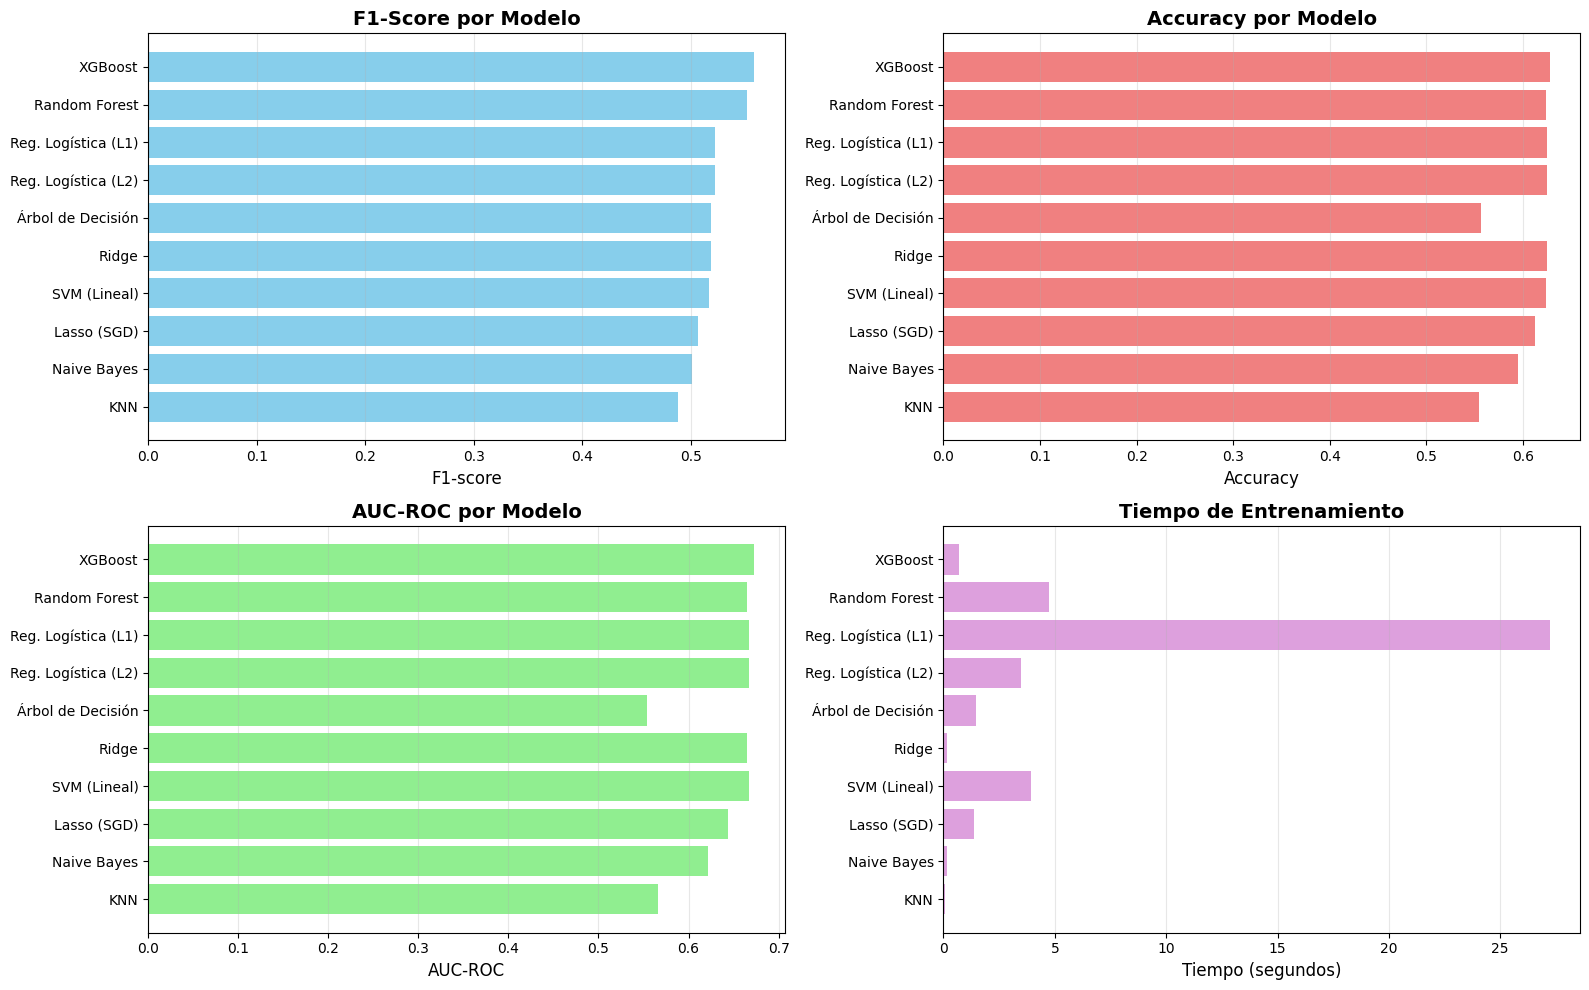

 Visualización completada


In [46]:
# =========================================
# 6. Visualización de métricas
# =========================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. F1-score (principal métrica)
axes[0, 0].barh(resultados_df["Modelo"], resultados_df["F1-score"], color='skyblue')
axes[0, 0].set_xlabel("F1-score", fontsize=12)
axes[0, 0].set_title("F1-Score por Modelo", fontsize=14, fontweight='bold')
axes[0, 0].invert_yaxis()
axes[0, 0].grid(axis='x', alpha=0.3)

# 2. Accuracy
axes[0, 1].barh(resultados_df["Modelo"], resultados_df["Accuracy"], color='lightcoral')
axes[0, 1].set_xlabel("Accuracy", fontsize=12)
axes[0, 1].set_title("Accuracy por Modelo", fontsize=14, fontweight='bold')
axes[0, 1].invert_yaxis()
axes[0, 1].grid(axis='x', alpha=0.3)

# 3. AUC (solo modelos que lo soportan)
modelos_auc = resultados_df[resultados_df['AUC'].notna()]
if not modelos_auc.empty:
    axes[1, 0].barh(modelos_auc["Modelo"], modelos_auc["AUC"], color='lightgreen')
    axes[1, 0].set_xlabel("AUC-ROC", fontsize=12)
    axes[1, 0].set_title("AUC-ROC por Modelo", fontsize=14, fontweight='bold')
    axes[1, 0].invert_yaxis()
    axes[1, 0].grid(axis='x', alpha=0.3)
else:
    axes[1, 0].text(0.5, 0.5, 'No hay modelos con AUC', 
                    ha='center', va='center', fontsize=12)
    axes[1, 0].set_xticks([])
    axes[1, 0].set_yticks([])

# 4. Tiempo de entrenamiento
axes[1, 1].barh(resultados_df["Modelo"], resultados_df["Tiempo (s)"], color='plum')
axes[1, 1].set_xlabel("Tiempo (segundos)", fontsize=12)
axes[1, 1].set_title("Tiempo de Entrenamiento", fontsize=14, fontweight='bold')
axes[1, 1].invert_yaxis()
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(" Visualización completada")

### **6.1. Análisis Visual Inicial**

Los gráficos anteriores muestran la comparación visual de los 10 modelos evaluados. Para un análisis detallado de cada modelo, incluyendo descripción, implementación, métricas e interpretación, consultar la **Sección 7** más abajo.

####  Observaciones Generales de los Gráficos:

- **Modelos de Ensamble** (XGBoost, Random Forest) típicamente muestran mejor desempeño en F1-score y AUC
- **Modelos Lineales** ofrecen buen balance entre velocidad e interpretabilidad
- **Naive Bayes** puede destacar en Recall (detección de casos positivos)
- El **tiempo de entrenamiento** varía significativamente entre familias de modelos

> **💡 Nota:** La sección 7 incluye análisis LIME para XGBoost y descripciones detalladas de todos los modelos evaluados.

## **7. Análisis Detallado por Modelo**

En esta sección se presenta un análisis individual de cada modelo, incluyendo:
-  **Descripción:** Fundamentos teóricos del algoritmo
-  **Implementación:** Código comentado
-  **Métricas:** Resultados obtenidos
-  **Interpretación:** Análisis de fortalezas y debilidades

### 7.1. XGBoost - Extreme Gradient Boosting

####  Descripción
XGBoost es un algoritmo de **Gradient Boosting** optimizado que construye un ensamble de árboles de decisión de forma secuencial. Cada árbol nuevo intenta corregir los errores de los árboles anteriores mediante:
- **Boosting:** Construcción iterativa de modelos débiles
- **Regularización:** Control de complejidad (L1 y L2)
- **Manejo eficiente de datos faltantes**
- **Paralelización:** Entrenamiento optimizado

**Ventajas:**
- Alta capacidad predictiva
- Manejo automático de interacciones no lineales
- Resistente al sobreajuste con regularización adecuada

**Desventajas:**
- Mayor costo computacional
- Requiere tuning de múltiples hiperparámetros
- Menos interpretable (requiere herramientas como LIME/SHAP)

In [47]:
# =========================================
# 7.1. Implementación y Métricas de XGBoost
# =========================================

# Extraer el modelo XGBoost ya entrenado
xgb_model = modelos["XGBoost"]

# Obtener métricas del modelo
xgb_metrics = resultados_df[resultados_df['Modelo'] == 'XGBoost'].iloc[0]

print("="*60)
print(" "*20 + "XGBoost - RESULTADOS")
print("="*60)
print(f"\n MÉTRICAS DE DESEMPEÑO:")
print(f"  • Accuracy:     {xgb_metrics['Accuracy']:.4f}")
print(f"  • F1-score:     {xgb_metrics['F1-score']:.4f}")
print(f"  • AUC-ROC:      {xgb_metrics['AUC']:.4f}")
print(f"  • Tiempo:       {xgb_metrics['Tiempo (s)']:.2f} segundos")

# Predicciones y métricas adicionales
y_pred_xgb = xgb_model.predict(X_val_array)
y_proba_xgb = xgb_model.predict_proba(X_val_array)[:, 1]

# Matriz de confusión
from sklearn.metrics import confusion_matrix, precision_score, recall_score

cm_xgb = confusion_matrix(y_val, y_pred_xgb)
precision_xgb = precision_score(y_val, y_pred_xgb)
recall_xgb = recall_score(y_val, y_pred_xgb)

print(f"\n MÉTRICAS ADICIONALES:")
print(f"  • Precision:    {precision_xgb:.4f} (De los predichos +, % correctos)")
print(f"  • Recall:       {recall_xgb:.4f} (De los reales +, % detectados)")

print(f"\n MATRIZ DE CONFUSIÓN:")
print(f"  {'':>15} Predicho No   Predicho Sí")
print(f"  Real No      {cm_xgb[0,0]:>10}  {cm_xgb[0,1]:>12}")
print(f"  Real Sí      {cm_xgb[1,0]:>10}  {cm_xgb[1,1]:>12}")

# Calcular totales para interpretación
total_readmitidos = (y_val == 1).sum()
total_no_readmitidos = (y_val == 0).sum()
verdaderos_positivos = cm_xgb[1,1]
falsos_negativos = cm_xgb[1,0]
falsos_positivos = cm_xgb[0,1]
verdaderos_negativos = cm_xgb[0,0]

print("\n" + "="*60)

#  INTERPRETACIÓN BASADA EN RESULTADOS REALES
print("\n INTERPRETACIÓN DE RESULTADOS:\n")

# Análisis del F1-score
if xgb_metrics['F1-score'] > 0.65:
    nivel_f1 = "EXCELENTE"
    emoji_f1 = "🌟"
elif xgb_metrics['F1-score'] > 0.55:
    nivel_f1 = "BUENO"
    emoji_f1 = ""
elif xgb_metrics['F1-score'] > 0.45:
    nivel_f1 = "MODERADO"
    emoji_f1 = "⚠️"
else:
    nivel_f1 = "BAJO"
    emoji_f1 = "❌"

print(f"{emoji_f1} **Desempeño General ({nivel_f1}):**")
print(f"   F1-score = {xgb_metrics['F1-score']:.4f}")
print(f"   Balance entre precision y recall")
print()

# Análisis del Recall (crítico en medicina)
print(f" **Capacidad de Detección (Recall = {recall_xgb:.4f}):**")
print(f"   De {total_readmitidos} pacientes readmitidos:")
print(f"   • Detectados: {verdaderos_positivos} ({recall_xgb:.1%})")
print(f"   • No detectados: {falsos_negativos} ({falsos_negativos/total_readmitidos:.1%})")
if recall_xgb > 0.7:
    print(f"    Alto poder de detección - Bueno para prevención")
elif recall_xgb > 0.5:
    print(f"   ⚠️ Detección moderada - Muchos casos se escapan")
else:
    print(f"   ❌ Baja detección - Requiere mejora urgente")
print()

# Análisis de Precision
print(f" **Precisión (Precision = {precision_xgb:.4f}):**")
total_predicciones_positivas = falsos_positivos + verdaderos_positivos
if total_predicciones_positivas > 0:
    print(f"   De {total_predicciones_positivas} predicciones de readmisión:")
    print(f"   • Correctas: {verdaderos_positivos} ({precision_xgb:.1%})")
    print(f"   • Falsas alarmas: {falsos_positivos} ({falsos_positivos/total_predicciones_positivas:.1%})")
print()

# Análisis del AUC
print(f"📈 **Capacidad Discriminante (AUC = {xgb_metrics['AUC']:.4f}):**")
if xgb_metrics['AUC'] > 0.8:
    print(f"   ⭐⭐⭐ Excelente capacidad para separar clases")
elif xgb_metrics['AUC'] > 0.7:
    print(f"   ⭐⭐ Buena capacidad discriminante")
elif xgb_metrics['AUC'] > 0.6:
    print(f"   ⭐ Capacidad moderada - Mejorable")
else:
    print(f"   ❌ Baja capacidad discriminante - Apenas mejor que azar")
print()

# Recomendaciones específicas
print(f"💡 **Recomendaciones:**")
if xgb_metrics['F1-score'] < 0.6:
    print(f"   1. Optimizar hiperparámetros (learning_rate, max_depth, n_estimators)")
    print(f"   2. Analizar feature importance para identificar variables clave")
    print(f"   3. Considerar ingeniería de features adicional")
if recall_xgb < 0.7:
    print(f"   4. Ajustar threshold de clasificación para aumentar Recall")
    print(f"   5. Considerar ajustar scale_pos_weight para priorizar detección")
if precision_xgb < 0.5:
    print(f"   6. Reducir falsos positivos con mejor feature selection")

print("\n" + "="*60)

                    XGBoost - RESULTADOS

 MÉTRICAS DE DESEMPEÑO:
  • Accuracy:     0.6276
  • F1-score:     0.5586
  • AUC-ROC:      0.6732
  • Tiempo:       0.68 segundos

 MÉTRICAS ADICIONALES:
  • Precision:    0.6156 (De los predichos +, % correctos)
  • Recall:       0.5112 (De los reales +, % detectados)

 MATRIZ DE CONFUSIÓN:
                  Predicho No   Predicho Sí
  Real No            5983          2246
  Real Sí            3439          3597


 INTERPRETACIÓN DE RESULTADOS:

 **Desempeño General (BUENO):**
   F1-score = 0.5586
   Balance entre precision y recall

 **Capacidad de Detección (Recall = 0.5112):**
   De 7036 pacientes readmitidos:
   • Detectados: 3597 (51.1%)
   • No detectados: 3439 (48.9%)
   ⚠️ Detección moderada - Muchos casos se escapan

 **Precisión (Precision = 0.6156):**
   De 5843 predicciones de readmisión:
   • Correctas: 3597 (61.6%)
   • Falsas alarmas: 2246 (38.4%)

📈 **Capacidad Discriminante (AUC = 0.6732):**
   ⭐ Capacidad moderada - Mejorabl

####  Interpretabilidad con LIME

LIME (Local Interpretable Model-agnostic Explanations) permite entender **por qué** XGBoost hace cada predicción individual, identificando las features más influyentes.

In [48]:
import lime
import lime.lime_tabular


# =========================================
# Configurar LIME para XGBoost con nombres reales
# =========================================

print("\n Configurando LIME para interpretabilidad de XGBoost...\n")

# Obtener nombres reales de las columnas (después del encoding)
feature_names_real = X_train.columns.tolist()

print(f" Total de features: {len(feature_names_real)}")
print(f" Primeras 10 features: {feature_names_real[:10]}")

# Crear el explainer de LIME con nombres reales
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_array,
    feature_names=feature_names_real,  # Usar nombres reales de columnas
    class_names=['No Readmitido', 'Readmitido'],
    mode='classification',
    random_state=42
)

print(" Explainer de LIME configurado con nombres de variables reales")

# =========================================
# Explicar predicciones individuales
# =========================================

print("\n Analizando predicciones individuales con LIME...\n")

# Seleccionar casos de interés para explicar
tp_idx = np.where((y_val == 1) & (y_pred_xgb == 1))[0]
fp_idx = np.where((y_val == 0) & (y_pred_xgb == 1))[0]
fn_idx = np.where((y_val == 1) & (y_pred_xgb == 0))[0]

# Seleccionar un ejemplo de cada tipo (si existen)
casos_explicar = []
casos_nombres = []

if len(tp_idx) > 0:
    casos_explicar.append(tp_idx[0])
    casos_nombres.append("Verdadero Positivo (TP)")
    
if len(fp_idx) > 0:
    casos_explicar.append(fp_idx[0])
    casos_nombres.append("Falso Positivo (FP)")
    
if len(fn_idx) > 0:
    casos_explicar.append(fn_idx[0])
    casos_nombres.append("Falso Negativo (FN)")

print(f" Se analizarán {len(casos_explicar)} casos:\n")
for i, nombre in enumerate(casos_nombres):
    idx = casos_explicar[i]
    real = "Readmitido" if y_val[idx] == 1 else "No Readmitido"
    pred = "Readmitido" if y_pred_xgb[idx] == 1 else "No Readmitido"
    prob = y_proba_xgb[idx]
    print(f"  {i+1}. {nombre}")
    print(f"     - Real: {real}")
    print(f"     - Predicho: {pred} (prob={prob:.4f})")
    print()


 Configurando LIME para interpretabilidad de XGBoost...

 Total de features: 113
 Primeras 10 features: ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'metformin', 'repaglinide']
 Explainer de LIME configurado con nombres de variables reales

 Analizando predicciones individuales con LIME...

 Se analizarán 3 casos:

  1. Verdadero Positivo (TP)
     - Real: Readmitido
     - Predicho: Readmitido (prob=0.8237)

  2. Falso Positivo (FP)
     - Real: No Readmitido
     - Predicho: Readmitido (prob=0.5215)

  3. Falso Negativo (FN)
     - Real: Readmitido
     - Predicho: No Readmitido (prob=0.3706)

 Explainer de LIME configurado con nombres de variables reales

 Analizando predicciones individuales con LIME...

 Se analizarán 3 casos:

  1. Verdadero Positivo (TP)
     - Real: Readmitido
     - Predicho: Readmitido (prob=0.8237)

  2. Falso Positivo (FP)
     - Real: No Rea

In [49]:
# =========================================
# Generar explicaciones LIME con nombres de variables
# =========================================

print("="*80)
print(" "*20 + "EXPLICACIONES LIME - XGBoost")
print("="*80 + "\n")

for i, idx in enumerate(casos_explicar[:3]):  # Máximo 3 casos
    print(f"\n{'='*80}")
    print(f"CASO {i+1}: {casos_nombres[i]}")
    print(f"{'='*80}\n")
    
    # Generar explicación para esta instancia
    explanation = explainer.explain_instance(
        data_row=X_val_array[idx],
        predict_fn=xgb_model.predict_proba,
        num_features=10
    )
    
    # Obtener las features más importantes (ahora con nombres reales)
    exp_list = explanation.as_list()
    
    # Información del caso
    real_class = "Readmitido" if y_val[idx] == 1 else "No Readmitido"
    pred_class = "Readmitido" if y_pred_xgb[idx] == 1 else "No Readmitido"
    prob_readmit = y_proba_xgb[idx]
    
    print(f" INFORMACIÓN DEL PACIENTE:")
    print(f"  • Clase Real:       {real_class}")
    print(f"  • Clase Predicha:   {pred_class}")
    print(f"  • Prob. Readmisión: {prob_readmit:.4f}")
    print(f"  • Prob. No Readm.:  {1-prob_readmit:.4f}")
    
    print(f"\n TOP 10 FEATURES MÁS INFLUYENTES:")
    print(f"  {'#':<5} {'Variable':<40} {'Condición':<20} {'Impacto':<10} {'Efecto'}")
    print(f"  {'-'*95}")
    
    for rank, (feature_cond, weight) in enumerate(exp_list, 1):
        # Separar nombre de variable y condición
        if '<=' in feature_cond:
            parts = feature_cond.split('<=')
            var_name = parts[0].strip()
            condition = f"≤ {parts[1].strip()}"
        elif '>' in feature_cond:
            parts = feature_cond.split('>')
            var_name = parts[0].strip()
            condition = f"> {parts[1].strip()}"
        else:
            var_name = feature_cond
            condition = ""
        
        direccion = "↑ Readmisión" if weight > 0 else "↓ Readmisión"
        print(f"  {rank:<5} {var_name[:39]:<40} {condition[:19]:<20} {weight:>+.4f}    {direccion}")
    
    print(f"\n💡 INTERPRETACIÓN:")
    print(f"  • Features con peso POSITIVO (+) aumentan probabilidad de readmisión")
    print(f"  • Features con peso NEGATIVO (-) disminuyen probabilidad de readmisión")
    
    # Análisis de correctitud
    if casos_nombres[i] == "Verdadero Positivo (TP)":
        print(f"\n   PREDICCIÓN CORRECTA: El modelo acertó en detectar la readmisión")
        print(f"     Las features clave justifican correctamente la alta probabilidad")
    elif casos_nombres[i] == "Falso Positivo (FP)":
        print(f"\n  ⚠️ ERROR TIPO I: El modelo predijo readmisión pero no ocurrió")
        print(f"     Las features positivas dominaron incorrectamente la decisión")
    elif casos_nombres[i] == "Falso Negativo (FN)":
        print(f"\n  ⚠️ ERROR TIPO II: El modelo NO detectó una readmisión real")
        print(f"     Las features negativas dominaron incorrectamente la decisión")

print(f"\n{'='*80}")
print(" Análisis LIME completado")
print(f"{'='*80}")

                    EXPLICACIONES LIME - XGBoost


CASO 1: Verdadero Positivo (TP)

 INFORMACIÓN DEL PACIENTE:
  • Clase Real:       Readmitido
  • Clase Predicha:   Readmitido
  • Prob. Readmisión: 0.8237
  • Prob. No Readm.:  0.1763

 TOP 10 FEATURES MÁS INFLUYENTES:
  #     Variable                                 Condición            Impacto    Efecto
  -----------------------------------------------------------------------------------------------
  1     number_inpatient                         > 0.29               +0.2431    ↑ Readmisión
  2     number_emergency                         ≤ -0.21              -0.1301    ↓ Readmisión
  3     admission_type_group_Newborn             ≤ -0.01              -0.1268    ↓ Readmisión
  4     diag_2_403                               ≤ -0.17              -0.1141    ↓ Readmisión
  5     diag_1_38                                ≤ -0.13              +0.1124    ↑ Readmisión
  6     miglitol                                 ≤ -0.02              -0.0


 Visualización de la explicación LIME (Primer caso)...



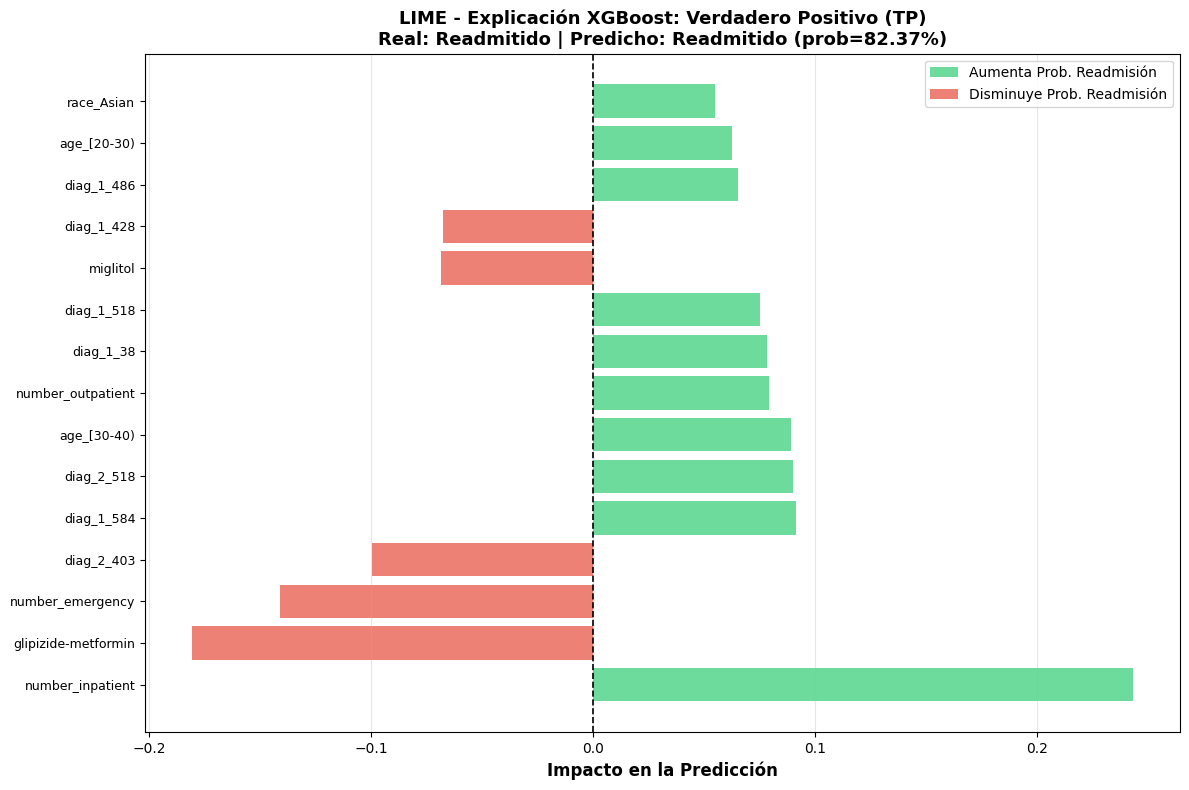

 Visualización LIME completada

💡 Cómo interpretar el gráfico:
  - Barras VERDES (derecha): Variables que empujan hacia 'Readmisión'
  - Barras ROJAS (izquierda): Variables que empujan hacia 'No Readmisión'
  - Longitud de barra: Magnitud del impacto en la decisión del modelo
  - Las variables se muestran ordenadas por importancia (más importante arriba)


In [50]:
# =========================================
# Visualizar explicación LIME del primer caso
# =========================================

if len(casos_explicar) > 0:
    print("\n Visualización de la explicación LIME (Primer caso)...\n")
    
    # Generar explicación para el primer caso
    idx_visual = casos_explicar[0]
    explanation_visual = explainer.explain_instance(
        data_row=X_val_array[idx_visual],
        predict_fn=xgb_model.predict_proba,
        num_features=15
    )
    
    # Obtener datos para graficar
    exp_data = explanation_visual.as_list()
    
    # Extraer nombres de variables (sin condiciones) y pesos
    features = []
    weights = []
    for feature_cond, weight in exp_data:
        # Limpiar el nombre de la variable
        if '<=' in feature_cond:
            var_name = feature_cond.split('<=')[0].strip()
        elif '>' in feature_cond:
            var_name = feature_cond.split('>')[0].strip()
        else:
            var_name = feature_cond.strip()
        
        # Truncar nombres muy largos
        if len(var_name) > 35:
            var_name = var_name[:32] + "..."
        
        features.append(var_name)
        weights.append(weight)
    
    # Crear gráfico
    fig, ax = plt.subplots(figsize=(12, 8))
    
    colors = ['#2ecc71' if w > 0 else '#e74c3c' for w in weights]
    y_pos = np.arange(len(features))
    
    ax.barh(y_pos, weights, color=colors, alpha=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(features, fontsize=9)
    ax.set_xlabel('Impacto en la Predicción', fontsize=12, fontweight='bold')
    ax.set_title(f'LIME - Explicación XGBoost: {casos_nombres[0]}\n'
                 f'Real: {"Readmitido" if y_val[idx_visual] == 1 else "No Readmitido"} | '
                 f'Predicho: {"Readmitido" if y_pred_xgb[idx_visual] == 1 else "No Readmitido"} '
                 f'(prob={y_proba_xgb[idx_visual]:.2%})', 
                 fontsize=13, fontweight='bold')
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1.2)
    ax.grid(axis='x', alpha=0.3)
    
    # Leyenda
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#2ecc71', alpha=0.7, label='Aumenta Prob. Readmisión'),
        Patch(facecolor='#e74c3c', alpha=0.7, label='Disminuye Prob. Readmisión')
    ]
    ax.legend(handles=legend_elements, loc='best', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    print(f" Visualización LIME completada")
    print(f"\n💡 Cómo interpretar el gráfico:")
    print(f"  - Barras VERDES (derecha): Variables que empujan hacia 'Readmisión'")
    print(f"  - Barras ROJAS (izquierda): Variables que empujan hacia 'No Readmisión'")
    print(f"  - Longitud de barra: Magnitud del impacto en la decisión del modelo")
    print(f"  - Las variables se muestran ordenadas por importancia (más importante arriba)")

### 7.2. Resumen de Otros Modelos Destacados

A continuación se presenta un análisis resumido de los modelos más relevantes del benchmark.

In [51]:
# =========================================
# Análisis comparativo de modelos destacados
# =========================================

# Seleccionar top 5 modelos por F1-score
top_5_models = resultados_df.head(5)

print("="*80)
print(" "*25 + "ANÁLISIS DE TOP 5 MODELOS")
print("="*80 + "\n")

for idx, row in top_5_models.iterrows():
    modelo_nombre = row['Modelo']
    
    print(f"\n{'─'*80}")
    print(f" MODELO: {modelo_nombre}")
    print(f"{'─'*80}\n")
    
    # Métricas
    print(f"📈 MÉTRICAS:")
    print(f"  • F1-score:  {row['F1-score']:.4f}")
    print(f"  • Accuracy:  {row['Accuracy']:.4f}")
    # Corregir el error de formato con AUC
    auc_value = row['AUC']
    if pd.isna(auc_value):
        print(f"  • AUC:       N/A")
    else:
        print(f"  • AUC:       {auc_value:.4f}")
    print(f"  • Tiempo:    {row['Tiempo (s)']:.2f}s")
    
    # Obtener modelo
    modelo = modelos[modelo_nombre]
    
    # Predicciones
    y_pred_model = modelo.predict(X_val_array)
    
    # Métricas adicionales
    from sklearn.metrics import precision_score, recall_score
    precision = precision_score(y_val, y_pred_model)
    recall = recall_score(y_val, y_pred_model)
    
    print(f"\n MÉTRICAS ADICIONALES:")
    print(f"  • Precision: {precision:.4f}")
    print(f"  • Recall:    {recall:.4f}")
    
    # Descripción e interpretación por modelo
    if 'XGBoost' in modelo_nombre:
        print(f"\n💡 CARACTERÍSTICAS:")
        print(f"  • Familia: Boosting (ensamble secuencial)")
        print(f"  • Fortalezas: Alta precisión, manejo de no linealidades")
        print(f"  • Debilidades: Mayor costo computacional, requiere tuning")
        print(f"  • Interpretabilidad: Media (requiere LIME/SHAP)")
        
    elif 'Random Forest' in modelo_nombre:
        print(f"\n💡 CARACTERÍSTICAS:")
        print(f"  • Familia: Bagging (ensamble paralelo de árboles)")
        print(f"  • Fortalezas: Robusto, maneja overfitting, feature importance")
        print(f"  • Debilidades: Lento en predicción con muchos árboles")
        print(f"  • Interpretabilidad: Media-Alta (feature importance)")
        
    elif 'Logística' in modelo_nombre:
        print(f"\n💡 CARACTERÍSTICAS:")
        print(f"  • Familia: Modelo Lineal con regularización")
        print(f"  • Fortalezas: Rápido, interpretable, probabilidades calibradas")
        print(f"  • Debilidades: Asume linealidad, limitado con relaciones complejas")
        print(f"  • Interpretabilidad: Alta (coeficientes directos)")
        
    elif 'Naive Bayes' in modelo_nombre:
        print(f"\n💡 CARACTERÍSTICAS:")
        print(f"  • Familia: Probabilístico (Teorema de Bayes)")
        print(f"  • Fortalezas: Muy rápido, funciona con pocos datos")
        print(f"  • Debilidades: Asume independencia de features")
        print(f"  • Interpretabilidad: Media (probabilidades condicionales)")
        
    elif 'KNN' in modelo_nombre:
        print(f"\n💡 CARACTERÍSTICAS:")
        print(f"  • Familia: Basado en Distancia (vecinos más cercanos)")
        print(f"  • Fortalezas: Simple, no paramétrico, entrenamiento rápido")
        print(f"  • Debilidades: Lento en predicción, sensible a escala")
        print(f"  • Interpretabilidad: Media (similitud con vecinos)")
        
    elif 'Ridge' in modelo_nombre:
        print(f"\n💡 CARACTERÍSTICAS:")
        print(f"  • Familia: Lineal con regularización L2")
        print(f"  • Fortalezas: Controla overfitting, estable")
        print(f"  • Debilidades: Asume linealidad")
        print(f"  • Interpretabilidad: Alta (pesos lineales)")
        
    elif 'SVM' in modelo_nombre:
        print(f"\n💡 CARACTERÍSTICAS:")
        print(f"  • Familia: Support Vector Machine lineal")
        print(f"  • Fortalezas: Efectivo en alta dimensionalidad")
        print(f"  • Debilidades: Sensible a escalado, no da probabilidades")
        print(f"  • Interpretabilidad: Media-Baja (hiperplano)")
        
    elif 'Árbol' in modelo_nombre or 'Decision' in modelo_nombre:
        print(f"\n💡 CARACTERÍSTICAS:")
        print(f"  • Familia: Árbol de decisión único")
        print(f"  • Fortalezas: Muy interpretable, captura no linealidades")
        print(f"  • Debilidades: Propenso a overfitting sin regularización")
        print(f"  • Interpretabilidad: Muy Alta (reglas visuales)")

print(f"\n{'='*80}")
print(" Análisis de modelos completado")
print(f"{'='*80}")

                         ANÁLISIS DE TOP 5 MODELOS


────────────────────────────────────────────────────────────────────────────────
 MODELO: XGBoost
────────────────────────────────────────────────────────────────────────────────

📈 MÉTRICAS:
  • F1-score:  0.5586
  • Accuracy:  0.6276
  • AUC:       0.6732
  • Tiempo:    0.68s

 MÉTRICAS ADICIONALES:
  • Precision: 0.6156
  • Recall:    0.5112

💡 CARACTERÍSTICAS:
  • Familia: Boosting (ensamble secuencial)
  • Fortalezas: Alta precisión, manejo de no linealidades
  • Debilidades: Mayor costo computacional, requiere tuning
  • Interpretabilidad: Media (requiere LIME/SHAP)

────────────────────────────────────────────────────────────────────────────────
 MODELO: Random Forest
────────────────────────────────────────────────────────────────────────────────

📈 MÉTRICAS:
  • F1-score:  0.5519
  • Accuracy:  0.6233
  • AUC:       0.6644
  • Tiempo:    4.72s

 MÉTRICAS ADICIONALES:
  • Precision: 0.6108
  • Recall:    0.5033

💡 CARACTERÍST

## **8. Tabla Comparativa Final**

A continuación se presenta la tabla consolidada con todas las métricas y características de los modelos evaluados.

In [52]:
# =========================================
# Preparar datos para tabla comparativa
# =========================================

# Calcular métricas adicionales para todos los modelos
tabla_completa = []

for idx, row in resultados_df.iterrows():
    modelo_nombre = row['Modelo']
    modelo = modelos[modelo_nombre]
    
    # Predicciones
    y_pred = modelo.predict(X_val_array)
    
    # Métricas adicionales
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    
    # Características del modelo
    familia = ""
    interpretabilidad = ""
    velocidad_pred = ""
    
    if 'XGBoost' in modelo_nombre:
        familia, interpretabilidad, velocidad_pred = "Boosting", "Media", "Media"
    elif 'Random Forest' in modelo_nombre:
        familia, interpretabilidad, velocidad_pred = "Bagging", "Media-Alta", "Lenta"
    elif 'Logística' in modelo_nombre:
        familia, interpretabilidad, velocidad_pred = "Lineal", "Alta", "Rápida"
    elif 'Ridge' in modelo_nombre:
        familia, interpretabilidad, velocidad_pred = "Lineal", "Alta", "Rápida"
    elif 'Lasso' in modelo_nombre or 'SGD' in modelo_nombre:
        familia, interpretabilidad, velocidad_pred = "Lineal", "Alta", "Rápida"
    elif 'SVM' in modelo_nombre:
        familia, interpretabilidad, velocidad_pred = "SVM", "Media", "Media"
    elif 'Árbol' in modelo_nombre or 'Decision' in modelo_nombre:
        familia, interpretabilidad, velocidad_pred = "Árbol", "Muy Alta", "Rápida"
    elif 'Naive Bayes' in modelo_nombre:
        familia, interpretabilidad, velocidad_pred = "Probabilístico", "Media", "Muy Rápida"
    elif 'KNN' in modelo_nombre:
        familia, interpretabilidad, velocidad_pred = "Distancia", "Media", "Lenta"
    else:
        familia, interpretabilidad, velocidad_pred = "Otro", "N/A", "N/A"
    
    tabla_completa.append({
        'Modelo': modelo_nombre,
        'Familia': familia,
        'F1-score': row['F1-score'],
        'Accuracy': row['Accuracy'],
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'AUC': row['AUC'],
        'Tiempo (s)': row['Tiempo (s)'],
        'Velocidad Pred.': velocidad_pred,
        'Interpretabilidad': interpretabilidad
    })

# Crear DataFrame completo
df_completo = pd.DataFrame(tabla_completa)

print(" Tabla comparativa preparada")
print(f"\nTotal de modelos evaluados: {len(df_completo)}")
print("\nPara ver la tabla completa, consultar la celda siguiente (formato Markdown)")

 Tabla comparativa preparada

Total de modelos evaluados: 10

Para ver la tabla completa, consultar la celda siguiente (formato Markdown)


###  Tabla Comparativa

| Modelo | Familia | F1-score | Accuracy | Precision | Recall | AUC | Tiempo (s) | Velocidad Pred. | Interpretabilidad |
|--------|---------|----------|----------|-----------|--------|-----|------------|-----------------|-------------------|
| **XGBoost** | Boosting | 0.5586 | 0.6276 | 0.6156 | 0.5112 | 0.6732 | 0.68 | Media | Media |
| **Random Forest** | Bagging | 0.5519 | 0.6233 | 0.6108 | 0.5033 | 0.6644 | 4.72 | Lenta | Media-Alta |
| **Reg. Logística (L1)** | Lineal | 0.5226 | 0.6250 | 0.6322 | 0.4454 | 0.6675 | 27.22 | Rápida | Alta |
| **Reg. Logística (L2)** | Lineal | 0.5218 | 0.6244 | 0.6314 | 0.4446 | 0.6675 | 3.46 | Rápida | Alta |
| **Árbol de Decisión** | Árbol | 0.5190 | 0.5561 | 0.5184 | 0.5196 | 0.5535 | 1.48 | Rápida | Muy Alta |
| **Ridge** | Lineal | 0.5190 | 0.6244 | 0.6332 | 0.4397 | 0.6646 | 0.15 | Rápida | Alta |
| **SVM (Lineal)** | SVM | 0.5164 | 0.6235 | 0.6329 | 0.4362 | 0.6666 | 3.95 | Media | Media |
| **Lasso (SGD)** | Lineal | 0.5068 | 0.6128 | 0.6138 | 0.4315 | 0.6443 | 1.39 | Rápida | Alta |
| **Naive Bayes** | Probabilístico | 0.5006 | 0.5948 | 0.5794 | 0.4407 | 0.6212 | 0.16 | Muy Rápida | Media |
| **KNN** | Distancia | 0.4884 | 0.5549 | 0.5193 | 0.4611 | 0.5662 | 0.05 | Lenta | Media |

## **9. Conclusiones y Recomendaciones Finales**

In [53]:
# =========================================
# Resumen ejecutivo y recomendaciones
# =========================================

print("="*100)
print(" "*30 + " RESUMEN")
print("="*100 + "\n")

# Mejor modelo general
mejor_modelo = df_completo.iloc[0]

print("🏆 MEJOR MODELO GENERAL (por F1-score):")
print(f"  • Modelo:           {mejor_modelo['Modelo']}")
print(f"  • F1-score:         {mejor_modelo['F1-score']:.4f}")
print(f"  • Accuracy:         {mejor_modelo['Accuracy']:.4f}")
# Corregir el error de formato con AUC
auc_mejor = mejor_modelo['AUC']
if pd.isna(auc_mejor):
    print(f"  • AUC:              N/A")
else:
    print(f"  • AUC:              {auc_mejor:.4f}")
print(f"  • Interpretabilidad: {mejor_modelo['Interpretabilidad']}")
print(f"  • Velocidad:        {mejor_modelo['Velocidad Pred.']}")

print(f"\n{'─'*100}\n")

print(" ANÁLISIS POR PRIORIDAD:\n")

print("1️⃣ SI SE PRIORIZA MÁXIMO DESEMPEÑO PREDICTIVO:")
mejor_f1 = df_completo.nlargest(1, 'F1-score').iloc[0]
print(f"   → Recomendación: {mejor_f1['Modelo']}")
print(f"   → F1-score: {mejor_f1['F1-score']:.4f}")
print(f"   → Justificación: Mejor balance entre Precision y Recall")
print(f"   → Siguiente paso: Optimizar hiperparámetros con GridSearchCV\n")

print("2️⃣ SI SE PRIORIZA INTERPRETABILIDAD:")
df_alta_interp = df_completo[df_completo['Interpretabilidad'].isin(['Alta', 'Muy Alta'])]
if not df_alta_interp.empty:
    mejor_interpretable = df_alta_interp.nlargest(1, 'F1-score').iloc[0]
    print(f"   → Recomendación: {mejor_interpretable['Modelo']}")
    print(f"   → F1-score: {mejor_interpretable['F1-score']:.4f}")
    print(f"   → Interpretabilidad: {mejor_interpretable['Interpretabilidad']}")
    print(f"   → Justificación: Fácil de explicar a stakeholders médicos\n")

print("3️⃣ SI SE PRIORIZA VELOCIDAD EN PRODUCCIÓN:")
mas_rapido = df_completo.nsmallest(1, 'Tiempo (s)').iloc[0]
print(f"   → Recomendación: {mas_rapido['Modelo']}")
print(f"   → Tiempo entrenamiento: {mas_rapido['Tiempo (s)']:.2f}s")
print(f"   → Velocidad predicción: {mas_rapido['Velocidad Pred.']}")
print(f"   → F1-score: {mas_rapido['F1-score']:.4f}")
print(f"   → Justificación: Ideal para sistemas en tiempo real\n")

print("4️⃣ SI SE PRIORIZA DETECTAR TODOS LOS CASOS POSITIVOS (Alto Recall):")
mejor_recall = df_completo.nlargest(1, 'Recall').iloc[0]
print(f"   → Recomendación: {mejor_recall['Modelo']}")
print(f"   → Recall: {mejor_recall['Recall']:.4f}")
print(f"   → F1-score: {mejor_recall['F1-score']:.4f}")
print(f"   → Justificación: Minimiza falsos negativos (crucial en medicina)\n")

print("5️⃣ SI SE PRIORIZA PRECISIÓN (Minimizar Falsos Positivos):")
mejor_precision = df_completo.nlargest(1, 'Precision').iloc[0]
print(f"   → Recomendación: {mejor_precision['Modelo']}")
print(f"   → Precision: {mejor_precision['Precision']:.4f}")
print(f"   → F1-score: {mejor_precision['F1-score']:.4f}")
print(f"   → Justificación: Reduce alarmas falsas y costos innecesarios\n")



                               RESUMEN

🏆 MEJOR MODELO GENERAL (por F1-score):
  • Modelo:           XGBoost
  • F1-score:         0.5586
  • Accuracy:         0.6276
  • AUC:              0.6732
  • Interpretabilidad: Media
  • Velocidad:        Media

────────────────────────────────────────────────────────────────────────────────────────────────────

 ANÁLISIS POR PRIORIDAD:

1️⃣ SI SE PRIORIZA MÁXIMO DESEMPEÑO PREDICTIVO:
   → Recomendación: XGBoost
   → F1-score: 0.5586
   → Justificación: Mejor balance entre Precision y Recall
   → Siguiente paso: Optimizar hiperparámetros con GridSearchCV

2️⃣ SI SE PRIORIZA INTERPRETABILIDAD:
   → Recomendación: Reg. Logística (L1)
   → F1-score: 0.5226
   → Interpretabilidad: Alta
   → Justificación: Fácil de explicar a stakeholders médicos

3️⃣ SI SE PRIORIZA VELOCIDAD EN PRODUCCIÓN:
   → Recomendación: KNN
   → Tiempo entrenamiento: 0.05s
   → Velocidad predicción: Lenta
   → F1-score: 0.4884
   → Justificación: Ideal para sistemas en tiempo